# Imoprts

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

/Users/ilabarymov/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/ilabarymov/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Config

In [2]:
class Config:
    seed = 42
    test_size = 0.2
    batch_size = 64
    lr = 0.001
    weight_decay = 1e-4
    dropout_rate = 0.3
    patience = 15
    epochs = 200

torch.manual_seed(Config.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/Users/ilabarymov/anaconda3/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 001 | Train Loss: 0.4444 | Val Loss: 1.4925 | R² Score: -0.4707
Epoch 002 | Train Loss: 0.2952 | Val Loss: 2.8387 | R² Score: -1.7973
Epoch 003 | Train Loss: 0.2656 | Val Loss: 1.4246 | R² Score: -0.4040
Epoch 004 | Train Loss: 0.2398 | Val Loss: 1.9744 | R² Score: -0.9457
Epoch 005 | Train Loss: 0.2224 | Val Loss: 0.8264 | R² Score: 0.1856
Epoch 006 | Train Loss: 0.2057 | Val Loss: 1.1384 | R² Score: -0.1220
Epoch 007 | Train Loss: 0.2058 | Val Loss: 1.6111 | R² Score: -0.5878
Epoch 008 | Train Loss: 0.1958 | Val Loss: 3.2113 | R² Score: -2.1650
Epoch 009 | Train Loss: 0.1901 | Val Loss: 1.9821 | R² Score: -0.9527
Epoch 010 | Train Loss: 0.1829 | Val Loss: 3.3290 | R² Score: -2.2803
Epoch 011 | Train Loss: 0.1772 | Val Loss: 12.0854 | R² Score: -10.9076
Epoch 012 | Train Loss: 0.1545 | Val Loss: 1.5582 | R² Score: -0.5356
Epoch 013 | Train Loss: 0.1475 | Val Loss: 17.1143 | R² Score: -15.8617
Epoch 014 | Train Loss: 0.1421 | Val Loss: 0.6693 | R² Score: 0.3404
Epoch 015 | Train 

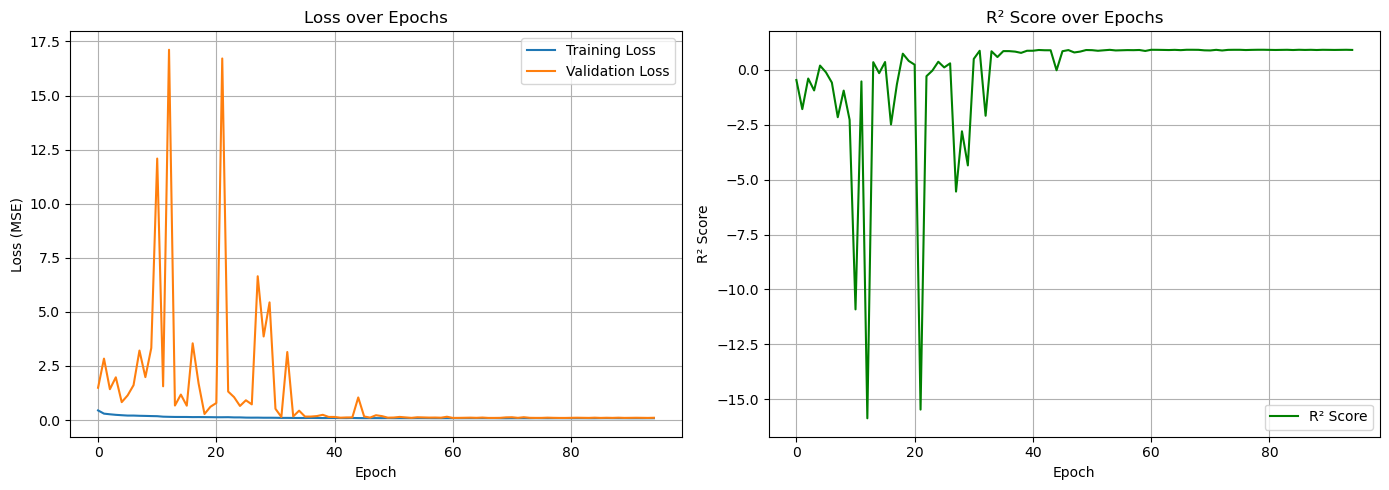


Final Metric
R²: 0.8971


In [8]:
def load_data():
    df = pd.read_csv('encoded_scaled_df.csv', index_col=0)
    df = df.drop(['Unnamed: 0.1', 'Unnamed: 0', 'Sales'], axis=1, errors='ignore')
    
    X = df.drop('Price', axis=1).values
    y = df['Price'].values.reshape(-1, 1)
    
    return X, y

X, y = load_data()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=Config.test_size, random_state=Config.seed
)

def to_tensor(data, device):
    return torch.FloatTensor(data).to(device)

X_train_tensor = to_tensor(X_train, device)
y_train_tensor = to_tensor(y_train, device)
X_test_tensor = to_tensor(X_test, device)
y_test_tensor = to_tensor(y_test, device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=Config.batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=Config.batch_size)

class EnhancedPricePredictor(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(Config.dropout_rate),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(0.1),
            nn.Dropout(Config.dropout_rate/2),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        return self.net(x)

model = EnhancedPricePredictor(X_train.shape[1]).to(device)
optimizer = optim.AdamW(model.parameters(), 
                      lr=Config.lr, 
                      weight_decay=Config.weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
                                               'min', 
                                               patience=5,
                                               factor=0.5,
                                               verbose=True)
criterion = nn.MSELoss()

class EarlyStopper:
    def __init__(self):
        self.best_loss = np.inf
        self.counter = 0
        
    def check(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= Config.patience:
                return True
        return False

early_stopper = EarlyStopper()

def train_model():
    history = {'train_loss': [], 'val_loss': [], 'r2': []}
    
    for epoch in range(Config.epochs):

        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        model.eval()
        val_loss = 0
        y_pred, y_true = [], []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                val_loss += criterion(outputs, y_batch).item()
                y_pred.extend(outputs.cpu().numpy())
                y_true.extend(y_batch.cpu().numpy())
        
        train_loss /= len(train_loader)
        val_loss /= len(test_loader)
        r2 = r2_score(y_true, y_pred)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['r2'].append(r2)
        
        scheduler.step(val_loss)
        
        print(f'Epoch {epoch+1:03d} | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'R² Score: {r2:.4f}')
        
        if early_stopper.check(val_loss):
            print("Early stopping triggered!")
            break
    
    return history

history = train_model()

def plot_training(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(history['train_loss'], label='Training Loss')
    ax1.plot(history['val_loss'], label='Validation Loss')
    ax1.set_title('Loss over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss (MSE)')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history['r2'], label='R² Score', color='green')
    ax2.set_title('R² Score over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('R² Score')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training(history)

def evaluate_model():
    model.eval()
    with torch.no_grad():
        test_preds = model(X_test_tensor).cpu().numpy()
        test_true = y_test_tensor.cpu().numpy()
        
        r2 = r2_score(test_true, test_preds)
        
    print(f'\nFinal Metric')
    print(f'R²: {r2:.4f}')

evaluate_model()

In [9]:
torch.save(model.state_dict(), 'price_predictor.pth')

Leaky ReLU

Final Metrics:

MAE: 0.17

RMSE: 0.34

R²: 0.8837

ReLU

Final Metrics:

MAE: 0.23

RMSE: 0.44

R²: 0.8064

In [ ]:
0.44 ** 2